In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import csv
import re

In [2]:
# # Read the .csv file
# dataset = "countries"
# root = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\"
# path = root + "experiments_" + dataset + ".csv"
# df = pd.read_csv(path, sep=';', keep_default_na=False)
# df.head()

In [38]:
tasks = ["countries", "pharmkg_supersmall"]
tasks = ["nations"] #,"kinship_family_small"]
root = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\"
for i,task in enumerate(tasks):
    path = root + "experiments_" + tasks[i] + ".csv"
    dfi = pd.read_csv(path, sep=';', keep_default_na=False)
    dfi = dfi.drop_duplicates()
    if i == 0:
        df = dfi
    else:
        df = pd.concat([df, dfi], ignore_index=True)
df = df.drop_duplicates()
print(df)

if 'countries' in tasks:
    # remove countries from the list tasks and add countries_s1, countries_s2, countries_s3
    tasks.remove('countries')
    tasks += ['countries_s1', 'countries_s2', 'countries_s3']

       Task    Grounder      KGE Rule_Miner  EmbedSize  WeightLoss_Task  \
0   nations       known  complex       ncrl        100              0.5   
1   nations       known  complex       amie        100              0.5   
2   nations       known  complex       None        100              0.5   
3   nations       known  complex       ncrl        100              0.5   
4   nations       known  complex       amie        100              0.5   
5   nations       known  complex       None        100              0.5   
6   nations       known  complex       ncrl        100              0.5   
7   nations       known  complex       amie        100              0.5   
8   nations       known  complex       None        100              0.5   
9   nations       known  complex       ncrl        100              0.5   
10  nations       known  complex       amie        100              0.5   
11  nations       known  complex       None        100              0.5   
12  nations       known  

In [39]:
print('converting the numbers as strings to lists')
for column in df:
    try:
        # For all the colum, apply eval() to convert the string to a list
        if column != 'KGE':
            df[column] = [np.array(eval(i)) for i in df[column].values]
    except:
        print("Error in ", column)
        continue

# for each col that is a string or int or object, print the unique values 
print('\nUnique values:')
for col in df.columns:
    try: 
        if df[col].dtype == 'object' or df[col].dtype == 'int64' or df[col].dtype == 'string':
            print(col,df[col].unique())
    except:
        continue

# results = df.loc[(df['Grounder'] == 'known') & (df['KGE'] == 'distmult') & (df['EmbedSize'] == 10)]

converting the numbers as strings to lists
Error in  Task
Error in  Grounder
Error in  Rule_Miner
Error in  EmbedSize
Error in  WeightLoss_Task
Error in  Reasoner_depth
Error in  Model_name

Unique values:
Task ['nations']
Grounder ['known' 'domainbody' 'backward_1' 'backward_2' 'backward_3']
KGE ['complex']
Rule_Miner ['ncrl' 'amie' 'None']
EmbedSize [100]
Reasoner_depth [1]
Model_name ['dcr' 'r2n' 'gsbr' 'cdcr' 'no_reasoner']


In [40]:
def split_df(df):
    # create a df that is the same as the original but with the first value of the colums in the list metrics
    df_mean = df.copy()
    for col in df_mean.columns:
        try:
            df_mean[col] = [i[0] for i in df_mean[col].values]
        except:
            continue
    # Do the same for the std
    df_std = df.copy()
    for col in df_std.columns:
        try:
            df_std[col] = [i[1] for i in df_std[col].values]
        except:
            continue
    return df_mean, df_std

In [41]:
cols = 'Grounder'
rows = 'Model_name'
metrics = ['test_task_mrr', 'Time']
KGEs = ['complex'] #, 'distmult', 'transe']
baseline_model = 'no_reasoner'
baseline_metric = 'test_concept_mrr'
# select the rows from df where the column models has the values ['dcr','mno_reasoner'] 
models = ['dcr','r2n','gsbr','cdcr','no_reasoner']
df = df.loc[df['Model_name'].isin(models)]

# Tables

One table for the different models with KGE complex (also for the other KGEs)
Another table for the different KGEs
Another table for the time with the best model and the best KGE

In [47]:
# Table 1: rows:grounder, cols:Model, values: mrr
csv_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\results.csv"
dfs = {}
for task in tasks:
    for metric in metrics:
        for KGE in ['complex']: #, 'distmult', 'transe']:
            for rule_miner in ['None', 'amie', 'ncrl']:
                print('KGE: ', KGE, ' Metric: ', metric, ' Task: ', task, ' Rule miner: ', rule_miner)
                # verify that the rule miner is within the values of Rule_Miner, else continue
                
                miners_available = df.loc[ (df['Task'] == task) &(df['KGE'] == KGE)]['Rule_Miner'].unique()
                if (rule_miner not in miners_available):
                    print('rule_miner',rule_miner)
                    print(miners_available)
                    continue
                # filter the df
                results = df.loc[ (df['Task'] == task) &(df['KGE'] == KGE) &(df['Rule_Miner'] == rule_miner) ].copy() #& (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
                # take only the columns grounder, model, test_task_mrr, test_concept_mrr
                results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
                # put the model_name as colums
                n_rows_before = len(results.index)
                cols_subset = [i for i in results.columns if i != 'test_task_mrr']
                results = results.drop_duplicates(subset=[cols,rows], keep='first')
                n_rows_after = len(results.index)
                print('n_rows_before',n_rows_before, 'n_rows_after', n_rows_after) if n_rows_before != n_rows_after else None
                results = results.pivot(index=rows, columns=cols, values=metric)
                # print(results)
                if metric == 'test_task_mrr':
                    # in the column no_reasoner, put the values of the column test_concept_mrr
                    substitute = df.loc[(df['Task'] == task) & (df['KGE'] == KGE) & (df['Model_name'] == baseline_model)][[cols,rows,baseline_metric]] #& (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)][[cols,rows,baseline_metric]]
                    n_rows_before = len(results.index)
                    # print('substitute',substitute)
                    # drop the duplicates, based on all the colums except for 'test_task_mrr'
                    cols_subset = [i for i in substitute.columns if i != 'test_task_mrr'] 
                    substitute = substitute.drop_duplicates(subset=[cols,rows], keep='first')
                    # print('\n\nsubstitute after',substitute)
                    n_rows_after = len(substitute.index)
                    print('n_rows_before',n_rows_before, 'n_rows_after', n_rows_after) if n_rows_before != n_rows_after else None
                        
                    # print('\nsubstitute',substitute)
                    substitute = substitute.pivot(index=rows, columns=cols, values=baseline_metric)
                    # substitute the values in the table
                    results.loc[baseline_model] = substitute.loc[baseline_model] 
                    print('\n\nresults',results)

                # with open(csv_dir, 'a') as f:
                #     f.write('\n Task : ,' + task + 'KGE : ,' + KGE + ', Metric: ,' + metric)
                #     f.write('\n ') 
                # results.to_csv(csv_dir, mode='a', header=True)  
results

KGE:  complex  Metric:  test_task_mrr  Task:  nations  Rule miner:  None
n_rows_before 19 n_rows_after 17
n_rows_before 5 n_rows_after 3


results Grounder           backward_1        backward_2        backward_3  \
Model_name                                                          
cdcr         [0.5962, 0.0104]    [0.601, 0.009]               NaN   
dcr                       NaN  [0.5955, 0.0046]  [0.6007, 0.0068]   
gsbr                      NaN  [0.6049, 0.0089]               NaN   
no_reasoner  [0.6033, 0.0047]  [0.6053, 0.0083]               NaN   
r2n                       NaN  [0.6112, 0.0133]  [0.6046, 0.0119]   

Grounder           domainbody             known  
Model_name                                       
cdcr                      NaN  [0.7015, 0.0088]  
dcr          [0.6938, 0.0057]  [0.6943, 0.0086]  
gsbr         [0.6996, 0.0087]  [0.6945, 0.0107]  
no_reasoner               NaN  [0.7018, 0.0074]  
r2n          [0.6975, 0.0105]  [0.6947, 0.0094]  
KGE:  complex  Metr

Grounder,backward_1,backward_2,backward_3,domainbody,known
Model_name,,,,,
cdcr,NaN,"[597.9683898925781, 22.734223929532597]",NaN,NaN,"[746.493745470047, 19.564267848201553]"
dcr,NaN,"[427.4730285644531, 13.709057799149036]","[442.77783660888673, 5.970756598332873]","[543.0027976036072, 45.69640862876402]","[453.53305716514586, 5.796352188707149]"
gsbr,NaN,"[187.11777877807617, 3.2093836293777622]","[190.2410662651062, 23.497488623411126]","[272.4498639583588, 10.13616848959689]","[226.45984377861024, 2.2961634267388713]"
no_reasoner,"[89.00517091751098, 10.427053154133082]","[87.86811113357544, 3.8204671729556936]",NaN,NaN,"[96.33436880111694, 8.791805571415974]"
r2n,NaN,"[229.5885561466217, 4.369350561129762]","[253.5379448890686, 21.472976364279]","[334.2877932071686, 12.459292105805375]","[262.7601886749268, 13.448521587231811]"


In [43]:
# # Table 1: rows:grounder, cols:Model, values: mrr
# csv_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\code\\keras-ns\\experiments\\countries\\hparamsearch\\results.csv"
# cols = 'Grounder'
# rows = 'KGE'
# metrics = ['test_task_mrr','Time']
# for metric in metrics:
#     for model in df['Model_name'].unique():
#         # filter the df
#         results = df.loc[ (df['Model_name'] == model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
#         # take only the columns grounder, model, test_task_mrr, test_concept_mrr
#         results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
#         # put the model_name as colums
#         results = results.pivot(index=rows, columns=cols, values=metric)
#         # print(results)
#         # with open(csv_dir, 'a') as f:
#         #     f.write('\nModel : ,' + model + ', Metric: ,' + metric)
#         #     f.write('\n ')
#         # results.to_csv(csv_dir, mode='a', header=True)  
# results

# PLOTS

In [44]:
step = 'test'
metric = step+'_task_mrr'
baseline_metric = step+'_concept_mrr'
metrics = [step+'_task_mrr','Time']
metric_names = {step+'_task_mrr':'MRR', 'Time':'Time (s)'}

KGE:  complex  Metric:  test_task_mrr  Task:  nations  Rule miner:  None
Grounder           backward_1  backward_2        backward_3        domainbody  \
Model_name                                                                      
cdcr         [0.5962, 0.0104]      0.6010               NaN               NaN   
dcr                       NaN      0.5955  [0.6007, 0.0068]  [0.6938, 0.0057]   
gsbr                      NaN      0.6049               NaN  [0.6996, 0.0087]   
no_reasoner  [0.6033, 0.0047]      0.6053               NaN               NaN   
r2n                       NaN      0.6112  [0.6046, 0.0119]  [0.6975, 0.0105]   

Grounder      known  
Model_name           
cdcr         0.7015  
dcr          0.6943  
gsbr         0.6945  
no_reasoner  0.7018  
r2n          0.6947  


ValueError: setting an array element with a sequence.

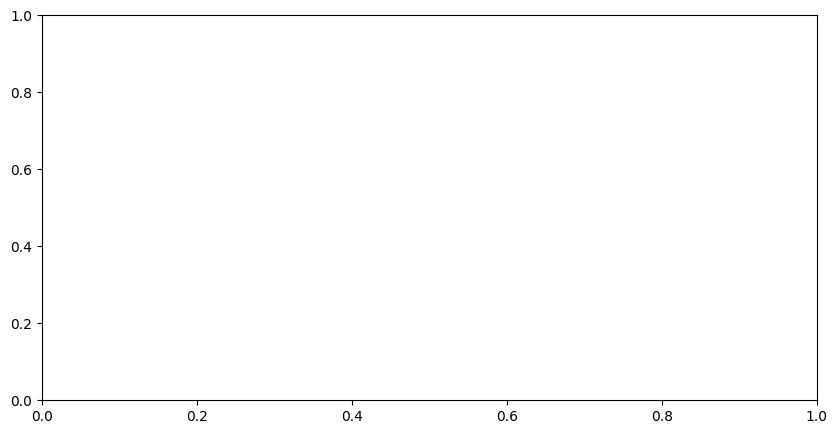

In [50]:
# Table 1: rows:grounder, cols:Model, values: mrr
root_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\figures\\"
os.makedirs(root_dir) if not os.path.exists(root_dir) else None
for task in tasks:
    for metric in metrics:
        for KGE in KGEs:
            for rule_miner in ['None', 'amie', 'ncrl']:
                print('KGE: ', KGE, ' Metric: ', metric, ' Task: ', task, ' Rule miner: ', rule_miner)
                # verify that the rule miner is within the values of Rule_Miner, else continue
                miners_available = df.loc[ (df['Task'] == task) &(df['KGE'] == KGE)]['Rule_Miner'].unique()
                if (rule_miner not in miners_available):
                    print('rule_miner',rule_miner)
                    print(miners_available)
                    continue
                # filter the df
                results = df.loc[(df['Task'] == task) & (df['KGE'] == KGE) &(df['Rule_Miner'] == rule_miner) ].copy() #& (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
                # take only the columns grounder, model, test_task_mrr, test_concept_mrr
                results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
                cols_subset = [i for i in results.columns if i != 'test_task_mrr']
                results = results.drop_duplicates(subset=[cols,rows], keep='first')
                # put the model_name as colums
                results = results.pivot(index=rows, columns=cols, values=metric)

                if metric == step+'_task_mrr':
                    # in the column no_reasoner, put the values of the columnstep+ _concept_mrr
                    substitute = df.loc[(df['Task'] == task) & (df['KGE'] == KGE) & (df['Model_name'] == baseline_model) &(df['Rule_Miner'] == rule_miner) ][[cols,rows,baseline_metric]] # & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)][[cols,rows,baseline_metric]]
                    cols_subset = [i for i in substitute.columns if i != 'test_task_mrr'] 
                    substitute = substitute.drop_duplicates(subset=[cols,rows], keep='first')
                    substitute = substitute.pivot(index=rows, columns=cols, values=baseline_metric)
                    # substitute the values in the table
                    results.loc[baseline_model] = substitute.loc[baseline_model]
                df_mean, df_std = split_df(results)
                # df_mean.fillna(0, inplace=True)
                # df_std.fillna(0, inplace=True)
                print(df_mean)
                # Remove no reasoner and include a line where it is written baseline
                plt.figure(figsize=(10,5))
                for i,grounder in enumerate(df_mean.columns):
                    plt.scatter(np.arange(len(df_mean.loc[models].index))+0.1*i, df_mean.loc[models][grounder], label=grounder, alpha=0.5)
                    plt.errorbar(np.arange(len(df_mean.loc[models].index))+0.1*i, df_mean.loc[models][grounder], yerr=df_std.loc[models][grounder], fmt='o',capsize=5, alpha=0.5)
                if metric == step+'_task_mrr':
                    plt.axhline(y=df_mean.loc[baseline_model].values[0], color='black', linestyle='--', alpha=.7)  # Change color and linestyle as desired
                    plt.text(1.8, df_mean.loc[baseline_model].values[0]-0.005, 'Baseline', color='black', fontsize=12, ha='center')
                    # print(df_mean.loc[baseline_model].values[0])
                plt.legend()
                plt.xticks(np.arange(len(df_mean.loc[models].index))+0.2, df_mean.loc[models].index.tolist(), rotation=0)
                plt.ylabel(metric_names[metric])
                plt.xlabel('Model')
                if rule_miner == 'None':
                    plt.title(f'Grounders across models. Task: {task}, KGE: {KGE}, Set: {step}')
                else:
                    plt.title(f'Grounders across models. Task: {task}, KGE: {KGE}, Set: {step}, Rule miner: {rule_miner}')
                # plt.show()
                # SAVE THE FIGURE
                # if the directory does not exist, create it
                plt.savefig(root_dir+'Grounders_across_models__'+'Task_'+task+'_Metric_'+metric+'_KGE_'+KGE+'_rule_'+rule_miner+'.png', dpi=300, bbox_inches='tight')  

In [10]:
# cols = 'Grounder'
# rows = 'KGE'
# metric = 'test_task_mrr'
# baseline_model = 'no_reasoner'
# baseline_metric = 'test_concept_mrr'
# for metric in ['test_task_mrr', 'Time']:
#     for model in df['Model_name'].unique():
#         if model !='no_reasoner':
#             # filter the df
#             results = df.loc[ (df['Model_name'] == model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
#             # take only the columns grounder, model, test_task_mrr, test_concept_mrr
#             results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
#             # put the model_name as colums
#             results = results.pivot(index=rows, columns=cols, values=metric)

#             df_mean, df_std = split_df(results)
#             # Remove no reasoner and include a line where it is written baseline
#             plt.figure(figsize=(10,5))
#             for i,grounder in enumerate(df_mean.columns):
#                 plt.scatter(np.arange(len(df_mean.index))+0.1*i, df_mean[grounder], label=grounder, alpha=0.5)
#                 plt.errorbar(np.arange(len(df_mean.index))+0.1*i, df_mean[grounder], yerr=df_std[grounder], fmt='o',capsize=5, alpha=0.5)
#             plt.legend()
#             plt.xticks(np.arange(len(df_mean.index))+0.1*i, df_mean.index.tolist(), rotation=0)
#             plt.ylabel('MRR test')
#             plt.xlabel('KGE')
#             plt.title(f'Grounders across KGEs for model {model}')
#             plt.show()
#             # plt.savefig(root_dir+'figures\\Grounders_across_KGE___Model_'+model+'.png', dpi=300, bbox_inches='tight')  